In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import matplotlib.colors as mcol
import matplotlib.cm as mcm
import scipy.stats as sts
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
import scipy.optimize as sopt
from sim_read import *

plt.rcParams["axes.linewidth"]  = 2
plt.rcParams["xtick.major.size"]  = 8
plt.rcParams["xtick.minor.size"]  = 3
plt.rcParams["ytick.major.size"]  = 8
plt.rcParams["ytick.minor.size"]  = 3
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams.update({'font.size': 24})
plt.rcParams.update({'font.family': 'serif'})
plt.rcParams["mathtext.default"] = 'rm'
plt.rcParams["mathtext.fontset"] = 'cm'

In [2]:
gls = sim(exgrp_fields=['GroupFirstSub'],exsub_fields=['SubhaloMass','SubhaloStellarPhotometrics'])
sim.mass_add(gls)

/Users/bhattacharyya.37/TNG50-1/sim_read.py:28: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst, 'group_m200', mconv + np.log10(self.hst.Group_M_Crit200))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:29: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst,'group_mst', mconv + np.log10(self.hst.GroupMassType[:,4]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:30: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mgas', mconv + np.log10(self.sub.SubhaloMassInRadType[:,0]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:31: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mst',mconv + np.log10(self.sub.SubhaloMassInRadType[:,4]))


In [6]:
h0 = 0.677
dconv = 1e-3/h0
mconv = 10 - np.log10(h0)

def samp_selc(floor=7.5,thresh=9.5,NN=5):
    massive_gal,dwarf_gal = dwf_select(gls.sub.mst,floor=7.5,thresh=9.5)
    all_gal = np.array([*dwarf_gal,*massive_gal])
    
    rh0 = len(all_gal)/50.0**3
    print(len(all_gal),rh0)

    back_gal = backspl_load()

    dhost = [[],[],[]]
    llg,llt,llh,llr = [[],[],[]],[[],[],[]],[[],[],[]],[[],[],[]]
    dhp,mdb = [[],[],[]],[[],[],[]]

    all_gal_tree =  KDTree(gls.sub.SubhaloPos[all_gal,:]) 
    massive_gal_tree = KDTree(gls.sub.SubhaloPos[massive_gal,:]) 

    for j in back_gal:
        lh = gls.sub.SubhaloGrNr[j]
        if gls.hst.group_m200[lh]>=9 and gls.hst.group_m200[lh]<11.5 and gls.sub.mst[j]<thresh and gls.sub.mst[j]>floor:
                dist, ind = massive_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                ind = massive_gal[ind]
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind[1:]])
            
                dhp[2].append(ind[1])
                mdb[2].append(ind[1+np.argmax(MD_mass - 3*np.log10(dist[1:]))])
                              
                dhost[2].append(dist[1])
                llt[2].append(max(MD_mass - 3*np.log10(dist[1:])) - 10.96)
                llh[2].append(lh)
                llg[2].append(j)
                    
                dist0, ind0 = all_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                dist0 *= dconv
                llr[2].append(0.2387324146*(NN+1)/dist0[-1]**3)

        dwarf_gal = np.delete(dwarf_gal,np.where(dwarf_gal==j)[0])

    dwarf_host,host_mem = np.unique(gls.sub.SubhaloGrNr[dwarf_gal],return_inverse=True)
    Ndh = len(dwarf_host)
    for i in range(Ndh):  
        lh = dwarf_host[i]
        #print(gls.hst.group_m200[lh])
        if gls.hst.group_m200[lh]>=9 and gls.hst.group_m200[lh]<11.5:
            #find_mem = dwarf_gal[np.where(host_mem==i)[0]]
            find_mem = dwarf_gal[np.where(host_mem==i)[0]]
            
            if len(find_mem)>=1: 
                stellar_sort = np.argsort(gls.sub.mst[find_mem])
                cen = find_mem[stellar_sort[-1]]
            
                dist, ind = massive_gal_tree.query(gls.sub.SubhaloPos[cen,:], k=NN+1)
                ind = massive_gal[ind]
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind[1:]])

                dhp[0].append(ind[1])
                mdb[0].append(ind[1+np.argmax(MD_mass - 3*np.log10(dist[1:]))])
    
                dhost[0].append(dist[1])
                llt[0].append(max(MD_mass - 3*np.log10(dist[1:])) - 10.96)
                llh[0].append(lh)
                llg[0].append(cen)
                
                dist0, ind0 = all_gal_tree.query(gls.sub.SubhaloPos[cen,:], k=NN+1)
                dist0 *= dconv
                llr[0].append(0.2387324146*(NN+1)/dist0[-1]**3)

                if len(find_mem)>1:
                    for j in find_mem[stellar_sort[:-1]]:
                        dist, ind = massive_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                        ind = massive_gal[ind]
                        dist *= dconv
                        MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind[1:]])
    
                        dhp[1].append(ind[1])
                        mdb[1].append(ind[1+np.argmax(MD_mass - 3*np.log10(dist[1:]))])
        
                        dhost[1].append(dist[1])
                        llt[1].append(max(MD_mass - 3*np.log10(dist[1:])) - 10.96)
                        llh[1].append(lh)
                        llg[1].append(j)
    
                        dist0, ind0 = all_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                        dist0 *= dconv
                        llr[1].append(0.2387324146*(NN+1)/dist0[-1]**3)
                        
        
    return llt,llh,llg,llr,dhost,dhp,mdb


In [7]:
massive_gal,dwarf_gal = dwf_select(gls.sub.mst,floor=7.5,thresh=9.5)
all_gal = np.array([*dwarf_gal,*massive_gal])

sfms_intercept,sfms_slope = dwf_sfms(gls.sub.mst,gls.sub.ssfr)

llt,llh,llg,llr,dhost,dhp,mdb = samp_selc()

N_lll = [len(llh[k]) for k in range(3)]
print(N_lll)
bin_mk = ['o','D','s']

1494 10829
1494 10829
-8.346120696830761 -0.17679571397785238
1494 10829
12323 0.098584
1257
[5103, 505, 375]


In [8]:
llg_a = np.array([m for i in range(3) for m in llg[i]])
mst_a = np.array([m for i in range(3) for m in gls.sub.mst[llg[i]]])
llt_a = np.array([t for i in range(3) for t in llt[i]])
llh_a = np.array([h for i in range(3) for h in llh[i]])
m200_a = gls.hst.group_m200[llh_a]
dhost_a = np.array([d for i in range(3) for d in dhost[i]])
llr_a = np.log10(np.array([r for i in range(3) for r in llr[i]])) - np.log10(0.142904)

ssfr_a = np.array([s for i in range(3) for s in gls.sub.ssfr[llg[i]]])
#qnc_a = 1-np.heaviside(ssfr_a-(sfms_intercept -1 + sfms_slope*np.array(mst_a)),1)
Nll = len(llh_a)

In [9]:
print(len(np.unique(llh_a)))

5449


In [10]:
bin_stellar = np.arange(9.5,11.5,0.2)

dg1 = massive_gal[np.where(gls.sub.ssfr[massive_gal]>-15)[0]]
bin_med, bin_edg, bin_n = sts.binned_statistic(gls.sub.mst[dg1],gls.sub.ssfr[dg1], statistic='median', bins=bin_stellar)

res = sts.linregress(bin_edg[:-1],bin_med)
print(res.intercept,res.slope)
'''
fig,ax=plt.subplots(figsize=(10,8))

sfr_seq = res.intercept + res.slope*bin_stellar
ax.scatter(gls.sub.mst[dg1],gls.sub.ssfr[dg1])
ax.plot(bin_stellar+0.1,sfr_seq,color='black',ls='--',lw=3)
ax.fill_between(bin_stellar+0.1,sfr_seq-1,sfr_seq+1,color='black',alpha=0.1)
'''

host_bins = [np.where(m200_a<11.5)[0],np.where(m200_a>=11.5)[0]]
bin_cols = ['teal','firebrick']

dw_samp = np.where(m200_a<11.5)[0]

-4.043278702457738 -0.620927639813141


0 0 651 1095
0 1 4281 3837
1 0 1379 1165
1 1 3154 3368
2 0 334 304
2 1 753 783


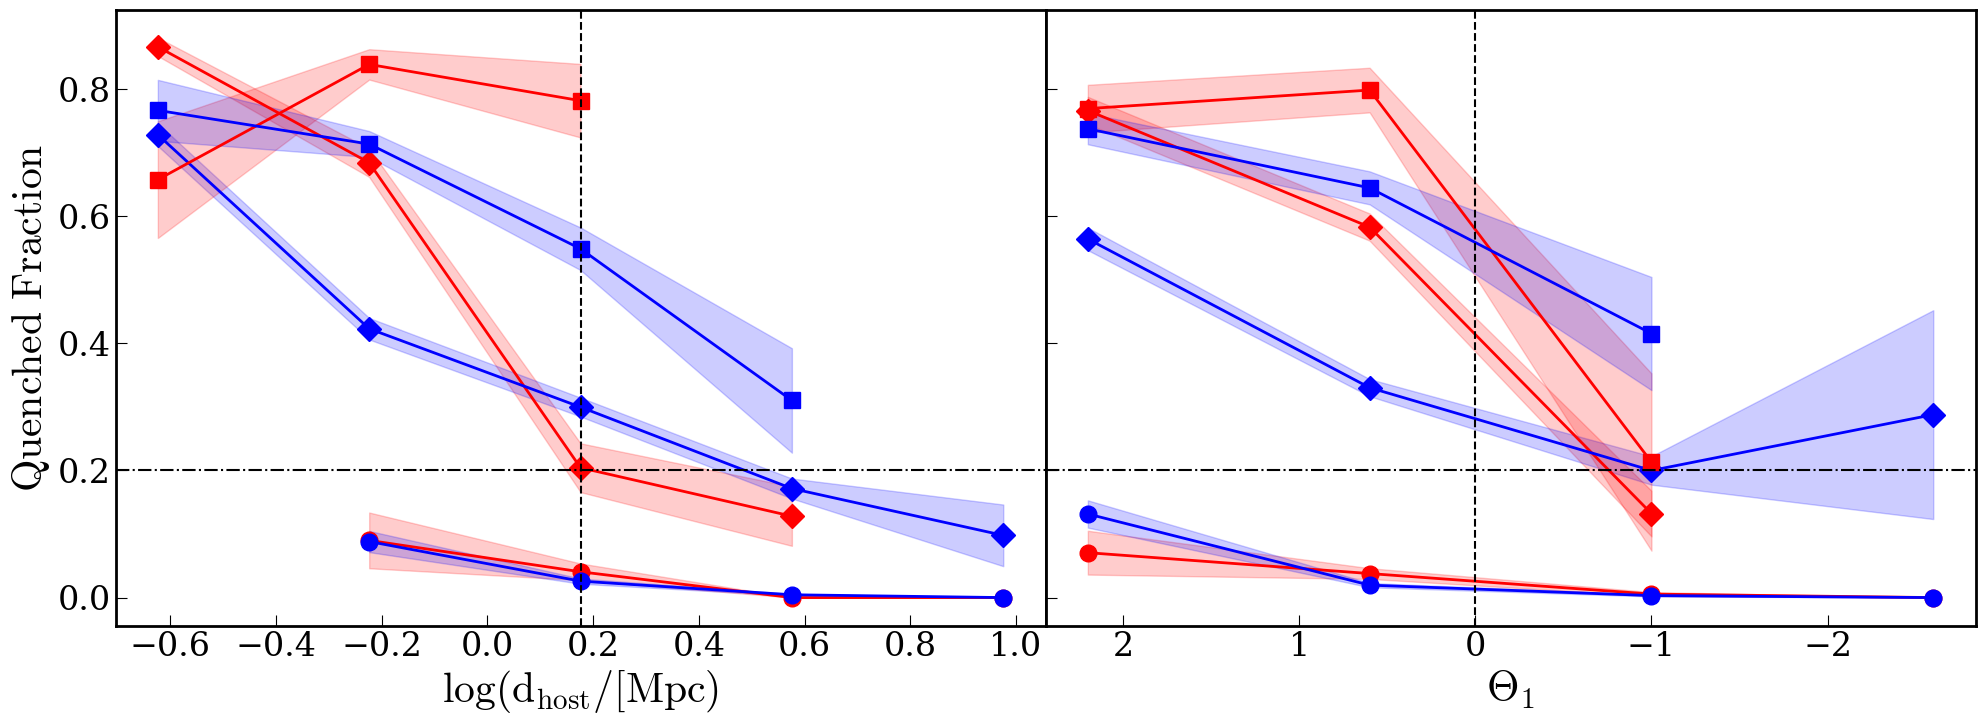

In [32]:
fig,ax=plt.subplots(1,2,figsize=(24,8),sharey=True)

bin_cols=['red','blue']
tracer_bins1 = [np.linspace(np.log10(0.15),np.log10(15),6),np.linspace(-5,3,6)]
tracer_bw1 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins1]

Nbtsp = 100

for k in range(3):
    dhmd_ssfr = [gls.sub.ssfr[dhp[k]]-(res.intercept -1 + res.slope*gls.sub.mst[dhp[k]]),gls.sub.ssfr[mdb[k]]-(res.intercept -1 + res.slope*gls.sub.mst[mdb[k]])]
    qsfhost = [np.where(dhmd_ssfr[0]<0)[0],np.where(dhmd_ssfr[1]<0)[0],np.where(dhmd_ssfr[0]>=0)[0],np.where(dhmd_ssfr[1]>=0)[0]]

    boot_qnc = np.zeros((4,Nbtsp,5))
    for j in range(2):
        print(k,j,len(qsfhost[2*j]),len(qsfhost[2*j+1]))
        for m in range(Nbtsp):
                boot = npr.choice(qsfhost[2*j],len(qsfhost[2*j]),replace=True)
        
                dhost_b = np.log10([dhost[k][i] for i in boot])
                mst_b = [gls.sub.mst[llg[k]][i] for i in boot]
                ssfr_b = [gls.sub.ssfr[llg[k]][i] for i in boot]
            
                qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
        
                bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins1[0])
                boot_qnc[2*j,m,:] = bin_qnc

                boot = npr.choice(qsfhost[2*j+1],size=len(qsfhost[2*j+1]),replace=True)
        
                llt_b = np.array([llt[k][i] for i in boot])
                mst_b = [gls.sub.mst[llg[k]][i] for i in boot]
                ssfr_b = [gls.sub.ssfr[llg[k]][i] for i in boot]
            
                qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
    
                bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_b,qnc_b,statistic='mean', bins=tracer_bins1[1])
                boot_qnc[2*j+1,m,:] = bin_qnc
            
    for j in range(2):
        boot_val = np.mean(boot_qnc[2*j,:,:],axis=0)
        boot_err = np.std(boot_qnc[2*j,:,:],axis=0,ddof=1)
    
        ax[0].plot(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val,lw=2,marker=bin_mk[k],color=bin_cols[j],markersize=12)
        ax[0].fill_between(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

        boot_val = np.mean(boot_qnc[2*j+1,:,:],axis=0)
        boot_err = np.std(boot_qnc[2*j+1,:,:],axis=0,ddof=1)
    
        ax[1].plot(tracer_bins1[1][:-1]+tracer_bw1[1],boot_val,lw=2,marker=bin_mk[k],color=bin_cols[j],markersize=12)
        ax[1].fill_between(tracer_bins1[1][:-1]+tracer_bw1[1],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)


for k in range(2):
    ax[k].axhline(0.2,color='black',ls='-.')

ax[0].axvline(np.log10(1.5),color='black',ls='--')
ax[1].axvline(0,color='black',ls='--')
ax[1].invert_xaxis()

ax[0].set_ylabel(r'$Quenched\ Fraction$',fontsize=30)
#ax[0].set_ylabel(r'$Quenching\ Efficiency$',fontsize=30)
ax[0].set_xlabel(r'$log(d_{host}/ [Mpc)$',fontsize=30)
ax[1].set_xlabel(r'$\Theta_1$',fontsize=30)

#custom_lines = [Line2D([0], [0],lw=3, color=bin_cols[0]), Line2D([0], [0],lw=3, color=bin_cols[1])]
#leg=Legend(ax[0],custom_lines,[r'$\mathcal{M}_{200}< 10^{11.5} M_{\odot}$',r'$\mathcal{M}_{200} >10^{11.5} M_{\odot}$'],loc='best',fontsize=26,framealpha=0.8,frameon=True)
#ax[0].add_artist(leg)

plt.subplots_adjust(wspace=0.0,hspace=0.0)
#plt.savefig('quenchtracer_geha12.pdf',bbox_inches='tight')


In [11]:
llg_c = np.array([m for i in range(2) for m in llg[i]])
mst_c = np.array([m for i in range(2) for m in gls.sub.mst[llg[i]]])
llt_c = np.array([t for i in range(2) for t in llt[i]])
llh_c = np.array([h for i in range(2) for h in llh[i]])
m200_c = gls.hst.group_m200[llh_c]
dhost_c = np.array([d for i in range(2) for d in dhost[i]])
llr_c = np.log10(np.array([r for i in range(2) for r in llr[i]])) - np.log10(0.142904)

ssfr_c = np.array([s for i in range(2) for s in gls.sub.ssfr[llg[i]]])
#qnc_c = 1-np.heaviside(ssfr_c-(sfms_intercept -1 + sfms_slope*np.array(mst_c)),1)
Nllc = len(llh_c)

dhp_a = np.array([t for i in range(3) for t in dhp[i]])
mdb_a = np.array([h for i in range(3) for h in mdb[i]])

dhp_c = np.array([t for i in range(2) for t in dhp[i]])
mdb_c = np.array([h for i in range(2) for h in mdb[i]])

0 856 1357
1 5127 4626
All 0 dhost [       nan 0.49021052 0.20375177 0.00923596 0.        ]
All 0 tidal [0.         0.01805596 0.098208   0.19802253 0.33245702]
All 1 dhost [       nan 0.30309509 0.08681432 0.01033988 0.00462691]
All 1 tidal [0.00718314 0.00743899 0.05695964 0.12029813 0.48466099]
0 730 1245
1 4878 4363
No Backsplash 0 dhost [       nan 0.15019301 0.04625411 0.00604081 0.        ]
No Backsplash 0 tidal [0.         0.00898485 0.0278477  0.05998656 0.17833763]
No Backsplash 1 dhost [       nan 0.11293487 0.03919582 0.00906663 0.00464551]
No Backsplash 1 tidal [0.00733461 0.00592877 0.02390802 0.05158045 0.20676839]


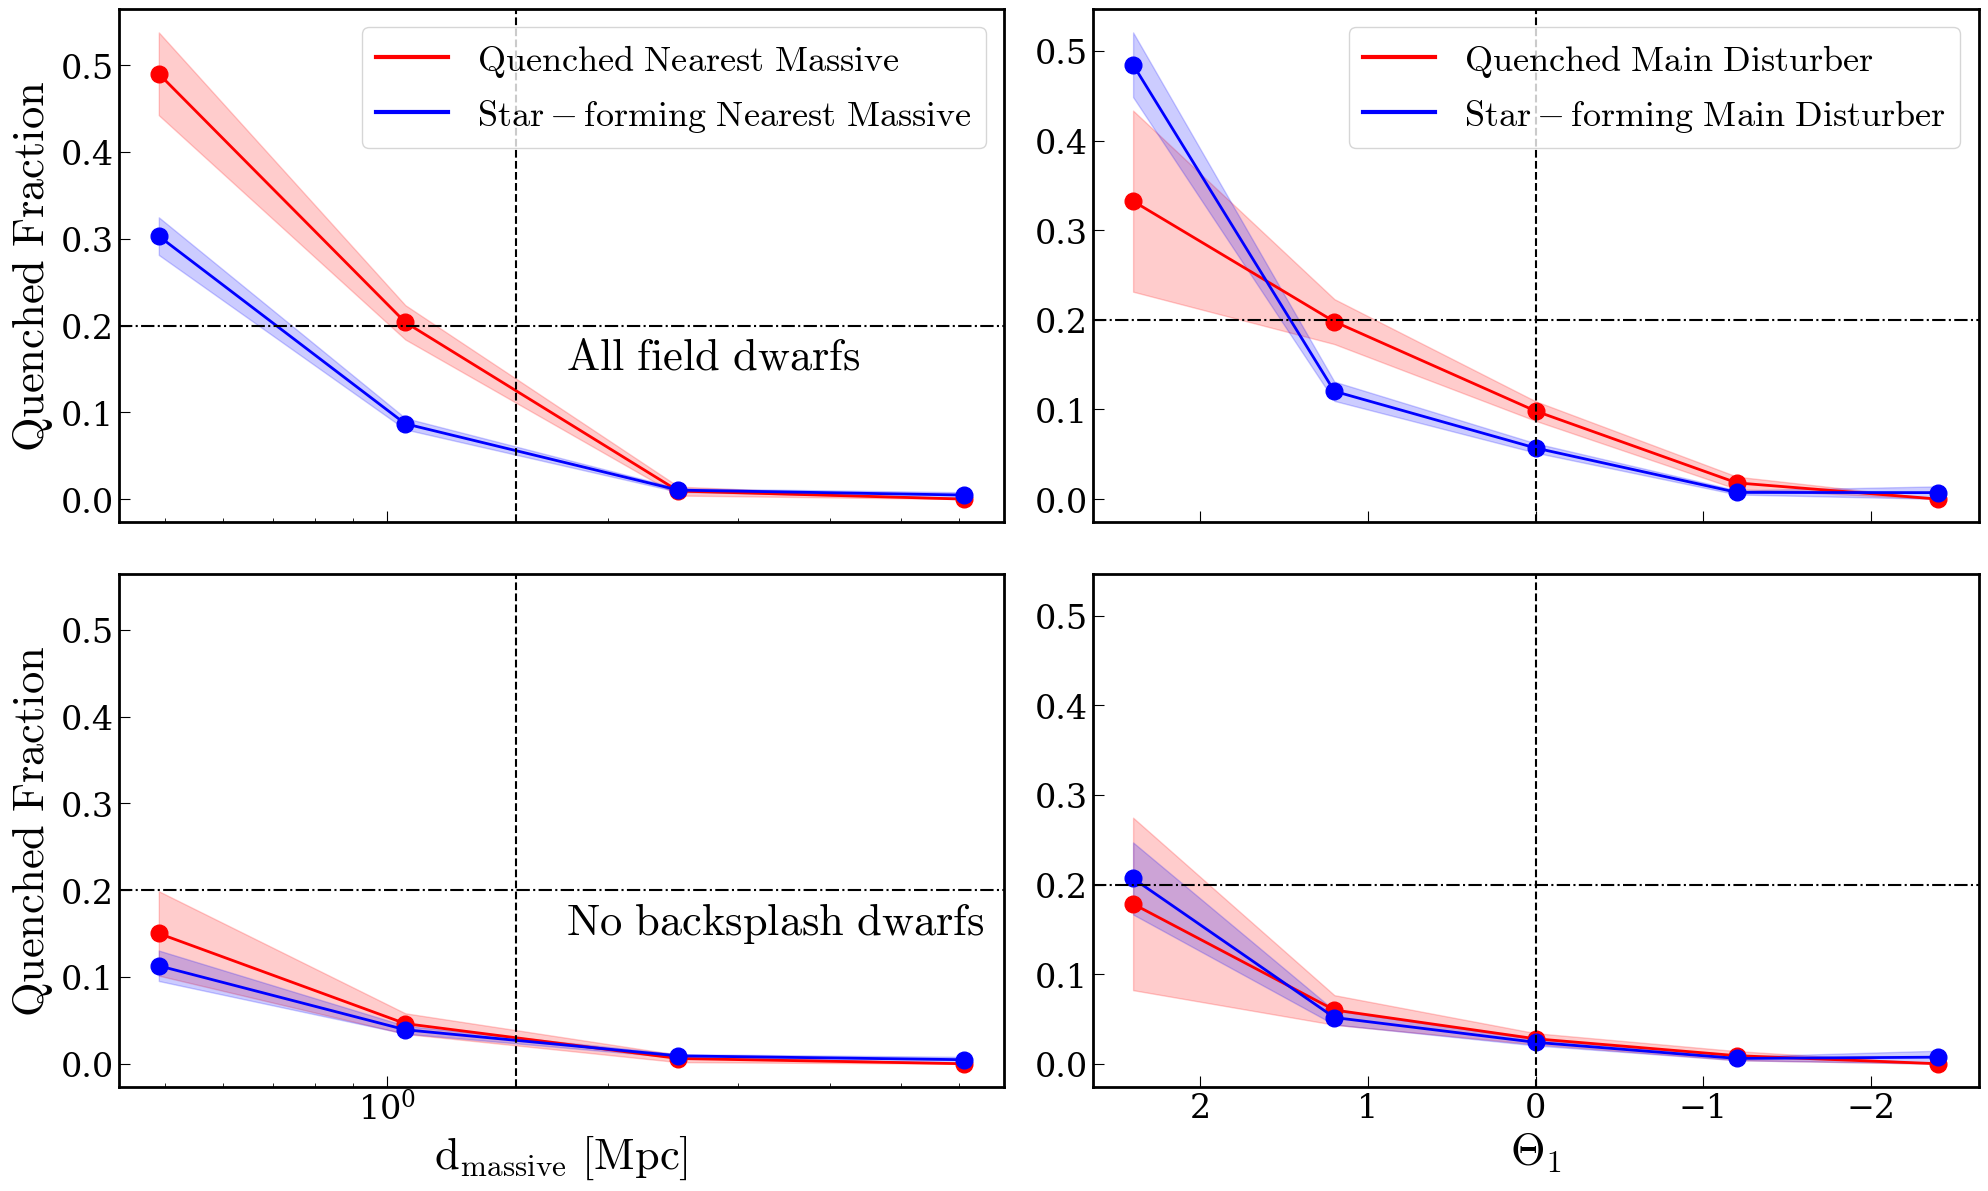

In [12]:
fig,ax=plt.subplots(2,2,figsize=(24,14),sharey='col',sharex='col')

bin_cols=['red','blue']
tracer_bins1 = [np.logspace(np.log10(0.15),np.log10(15),6),np.linspace(-3,3,6)]
tracer_bw1 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins1]

Nbtsp = 1000

dhmd_ssfr = [gls.sub.ssfr[dhp_a]-(res.intercept -1 + res.slope*gls.sub.mst[dhp_a]),gls.sub.ssfr[mdb_a]-(res.intercept -1 + res.slope*gls.sub.mst[mdb_a])]
qsfhost = [np.where((dhmd_ssfr[0]<0)&(m200_a<11.5))[0],np.where((dhmd_ssfr[1]<0)&(m200_a<11.5))[0],np.where((dhmd_ssfr[0]>=0)&(m200_a<11.5))[0],np.where((dhmd_ssfr[1]>=0)&(m200_a<11.5))[0]]

boot_qnc = np.zeros((4,Nbtsp,5))
for j in range(2):
    print(j,len(qsfhost[2*j]),len(qsfhost[2*j+1]))
    for m in range(Nbtsp):
            boot = npr.choice(qsfhost[2*j],len(qsfhost[2*j]),replace=True)
    
            dhost_b = [dhost_a[i] for i in boot]
            mst_b = [gls.sub.mst[llg_a[i]] for i in boot]
            ssfr_b = [gls.sub.ssfr[llg_a[i]] for i in boot]
        
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
    
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins1[0])
            boot_qnc[2*j,m,:] = bin_qnc

            boot = npr.choice(qsfhost[2*j+1],size=len(qsfhost[2*j+1]),replace=True)
    
            llt_b = np.array([llt_a[i] for i in boot])
            mst_b = [gls.sub.mst[llg_a[i]] for i in boot]
            ssfr_b = [gls.sub.ssfr[llg_a[i]] for i in boot]
        
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)

            bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_b,qnc_b,statistic='mean', bins=tracer_bins1[1])
            boot_qnc[2*j+1,m,:] = bin_qnc
        
for j in range(2):
    boot_val = np.mean(boot_qnc[2*j,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j,:,:],axis=0,ddof=1)

    print('All',j,'dhost',boot_val)

    ax[0,0].plot(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[0,0].fill_between(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

    boot_val = np.mean(boot_qnc[2*j+1,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j+1,:,:],axis=0,ddof=1)

    print('All',j,'tidal',boot_val)

    ax[0,1].plot(tracer_bins1[1][:-1]+tracer_bw1[1],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[0,1].fill_between(tracer_bins1[1][:-1]+tracer_bw1[1],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

tracer_bins1 = [np.logspace(np.log10(0.15),np.log10(15),6),np.linspace(-3,3,6)]
tracer_bw1 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins1]

dhmd_ssfr = [gls.sub.ssfr[dhp_c]-(res.intercept -1 + res.slope*gls.sub.mst[dhp_c]),gls.sub.ssfr[mdb_c]-(res.intercept -1 + res.slope*gls.sub.mst[mdb_c])]
qsfhost = [np.where((dhmd_ssfr[0]<0)&(m200_c<11.5))[0],np.where((dhmd_ssfr[1]<0)&(m200_c<11.5))[0],np.where((dhmd_ssfr[0]>=0)&(m200_c<11.5))[0],np.where((dhmd_ssfr[1]>=0)&(m200_c<11.5))[0]]

boot_qnc = np.zeros((4,Nbtsp,5))
for j in range(2):
    print(j,len(qsfhost[2*j]),len(qsfhost[2*j+1]))
    for m in range(Nbtsp):
            boot = npr.choice(qsfhost[2*j],len(qsfhost[2*j]),replace=True)
    
            dhost_b = [dhost_c[i] for i in boot]
            mst_b = [gls.sub.mst[llg_c[i]] for i in boot]
            ssfr_b = [gls.sub.ssfr[llg_c[i]] for i in boot]
        
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
    
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins1[0])
            boot_qnc[2*j,m,:] = bin_qnc

            boot = npr.choice(qsfhost[2*j+1],size=len(qsfhost[2*j+1]),replace=True)
    
            llt_b = np.array([llt_c[i] for i in boot])
            mst_b = [gls.sub.mst[llg_c[i]] for i in boot]
            ssfr_b = [gls.sub.ssfr[llg_c[i]] for i in boot]
        
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)

            bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_b,qnc_b,statistic='mean', bins=tracer_bins1[1])
            boot_qnc[2*j+1,m,:] = bin_qnc
        
for j in range(2):
    boot_val = np.mean(boot_qnc[2*j,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j,:,:],axis=0,ddof=1)

    print('No Backsplash',j,'dhost',boot_val)

    ax[1,0].plot(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[1,0].fill_between(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

    boot_val = np.mean(boot_qnc[2*j+1,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j+1,:,:],axis=0,ddof=1)

    print('No Backsplash',j,'tidal',boot_val)

    ax[1,1].plot(tracer_bins1[1][:-1]+tracer_bw1[1],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[1,1].fill_between(tracer_bins1[1][:-1]+tracer_bw1[1],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)


    for k in range(2):
        ax[j,k].axhline(0.2,color='black',ls='-.')

    ax[j,0].axvline(1.5,color='black',ls='--')
    ax[j,1].axvline(0,color='black',ls='--')

    ax[j,0].set_ylabel(r'$Quenched\ Fraction$',fontsize=32)
#ax[0].set_ylabel(r'$Quenching\ Efficiency$',fontsize=30)

ax[0,0].set_xscale('log')
ax[1,0].set_xscale('log')
ax[1,0].set_xlabel(r'$d_{massive}\ [Mpc]$',fontsize=32)
ax[1,1].set_xlabel(r'$\Theta_1$',fontsize=32)
ax[0,1].invert_xaxis()

ax[0,0].text(1.75,0.15,r'$All\ field\ dwarfs$',fontsize=32)
ax[1,0].text(1.75,0.15,r'$No\ backsplash\ dwarfs$',fontsize=32)

custom_lines = [Line2D([0], [0],lw=3, color='red'), Line2D([0], [0],lw=3, color='blue')]
leg=Legend(ax[0,0],custom_lines,[r'$Quenched\ Nearest\ Massive$',r'$Star-forming\ Nearest\ Massive$'],loc='best',fontsize=26,framealpha=0.8,frameon=True)
ax[0,0].add_artist(leg)

custom_lines = [Line2D([0], [0],lw=3, color='red'), Line2D([0], [0],lw=3, color='blue')]
leg=Legend(ax[0,1],custom_lines,[r'$Quenched\ Main\ Disturber$',r'$Star-forming\ Main\ Disturber$'],loc='best',fontsize=26,framealpha=0.8,frameon=True)
ax[0,1].add_artist(leg)

plt.subplots_adjust(wspace=0.1,hspace=0.1)
#plt.savefig('quench_conformity.pdf',bbox_inches='tight')


93


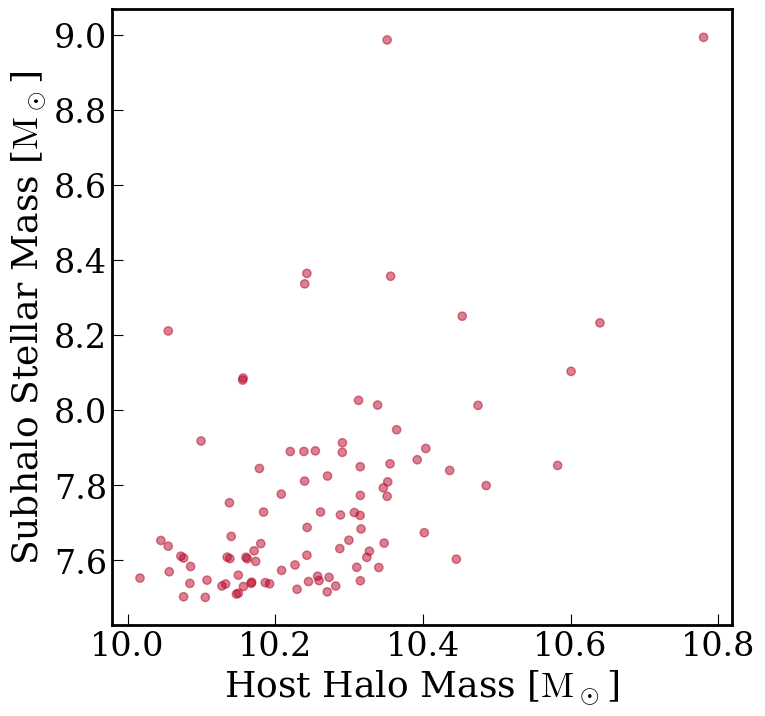

In [23]:
fig,ax=plt.subplots(figsize=(8,8),sharey=True)

m200_b = gls.hst.group_m200[llh[0]]
dhp_b = gls.sub.SubhaloGrNr[dhp[0]]
mst_b = gls.sub.mst[llg[0]]
ssfr_b = gls.sub.ssfr[llg[0]]
dsfms_b = ssfr_b-(sfms_intercept + sfms_slope*np.array(mst_b))
selc = np.where((dsfms_b<-1)&(m200_b<11))[0]
cand = np.array(llg[0])[selc]
print(len(selc))

ax.scatter(m200_b[selc],mst_b[selc],c=dsfms_b[selc],cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5,marker='o') 

ax.set_xlabel('Host Halo Mass [$M_\odot$]',fontsize=26)
ax.set_ylabel('Subhalo Stellar Mass [$M_\odot$]',fontsize=26)
plt.subplots_adjust(wspace=0.0)

35 0.3763440860215054 58 0.6236559139784946


Text(0, 0.5, '$v/V_{200}$')

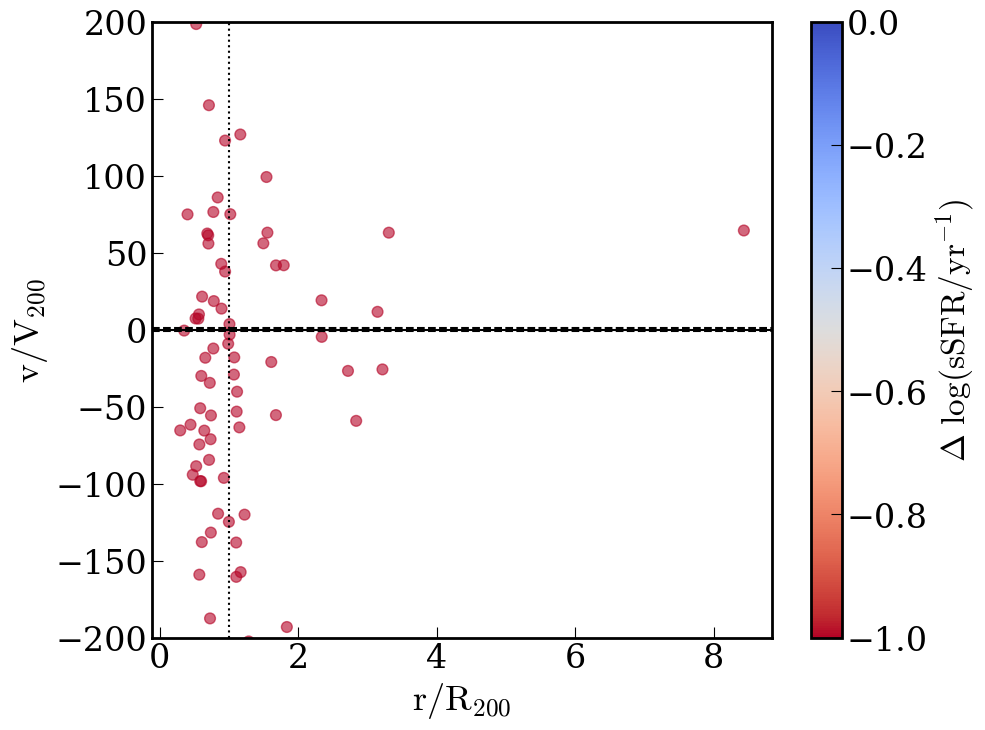

In [54]:
fig,ax=plt.subplots(figsize=(10,8))


grp_rad,grp_vel = [],[]
grp_col,grp_mrm = [],[]

r = wrap_dist(gls.sub.SubhaloPos[cand,:],gls.hst.GroupPos[dhp_b[selc],:])

rv = np.sum((gls.sub.SubhaloVel[cand,:]-gls.hst.GroupVel[dhp_b[selc],:])*(gls.sub.SubhaloPos[cand,:]-gls.hst.GroupPos[dhp_b[selc],:]),axis=1)
v = rv/r
#v = 4.8219e-3*v/np.sqrt(gls.hst.Group_M_Crit200[dhp_b[selc]]/gls.hst.Group_R_Crit200[dhp_b[selc]])
#r = r/gls.hst.Group_R_Crit200[dhp_b[selc]]
print(len(np.where(v>=0)[0]),len(np.where(v>=0)[0])/len(selc),len(np.where(v<0)[0]),len(np.where(v<0)[0])/len(selc))

ax.scatter(1e-3*r,v,c=dsfms_b[selc],s=60,cmap=mcm.coolwarm_r,vmin=-1,vmax=0,alpha=0.6)

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax, orientation='vertical',label=r'$\Delta\ log(sSFR/yr^{-1})$')


#ax.set_xlim((0,40))
ax.set_ylim((-200,200))
ax.axhline(-1,color='black',ls='--')
ax.axhline(0,color='black')
ax.axhline(1,color='black',ls='--')
ax.axvline(1,color='black',ls=':')

ax.set_xlabel(r'$r/R_{200}$',fontsize=26)
ax.set_ylabel(r'$v/V_{200}$',fontsize=26)
#plt.savefig('group_phasep.pdf',bbox_inches='tight')


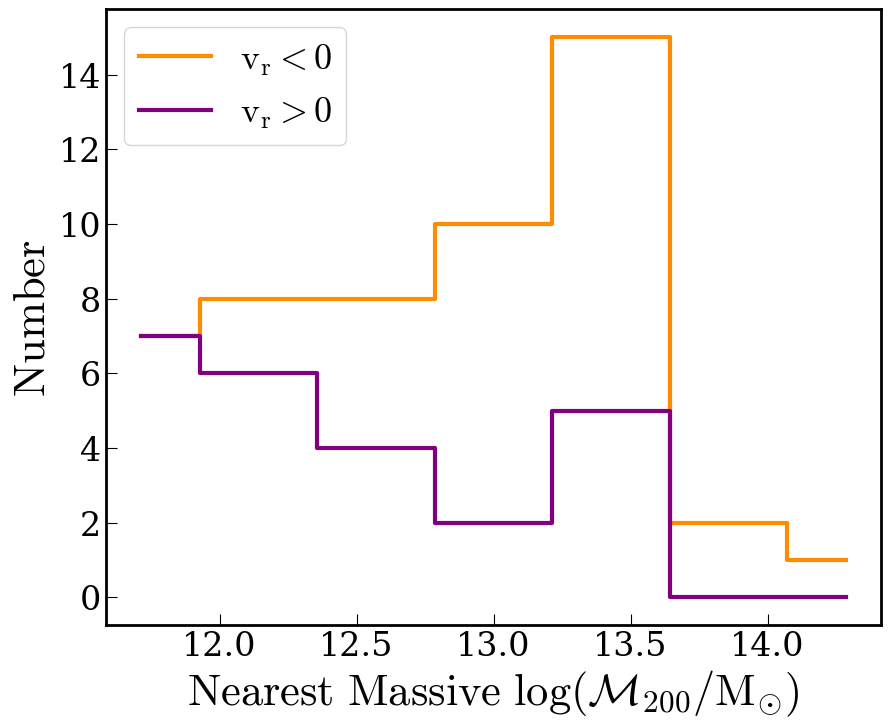

In [51]:
fig,ax=plt.subplots(figsize=(10,8))

mh_bins = np.linspace(11.5,14.5,8)
mh_bw = 0.5*(mh_bins[1]-mh_bins[0])

m200_dhp_vin = gls.hst.group_m200[dhp_b[selc[np.where(v<0)[0]]]]
m200_dhp_vout = gls.hst.group_m200[dhp_b[selc[np.where(v>=0)[0]]]]
    
bin_sat, bin_edg = np.histogram(m200_dhp_vin,bins=mh_bins)
ax.step(bin_edg[:-1]+mh_bw,bin_sat,color='darkorange',lw=3,where='mid',label=r'$v_r<0$')

bin_sat, bin_edg = np.histogram(m200_dhp_vout,bins=mh_bins)
ax.step(bin_edg[:-1]+mh_bw,bin_sat,color='purple',lw=3,where='mid',label=r'$v_r>0$')

ax.legend(loc='best',fontsize=26,frameon=True)
ax.set_ylabel(r'$Number$',fontsize=32)
ax.set_xlabel(r'$Nearest\ Massive\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=32)

plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('quench_infalls.pdf',bbox_inches='tight')

In [17]:
X1 = [[np.nan,0.32568503,0.13270615,0.00614619,0],[0.,0.0117993,0.06309147,0.12312562,0.23459056],[np.nan,0.18948074,0.06568509,0.00906426,0.00448586],[0.0071161,0.00664782,0.03788474,0.08169991,0.3708917 ]]
X2 = [[np.nan,0.10665752,0.03649459,0.00607483,0.        ],[0.,0.00861695,0.02494155,0.0531032,0.12474955],[np.nan,0.09682764,0.03727595,0.00863874,0.00466548],[0.00709338,0.00606725,0.02230378,0.04524813,0.17865897]]


for i in range(4):
    print(-100*(np.array(X2[i])-np.array(X1[i]))/np.array(X1[i]))

[        nan 67.25132868 72.49969952  1.16104448         nan]
[        nan 26.97066775 60.46763532 56.87071464 46.82243395]
[        nan 48.8984263  43.25051545  4.6944814  -4.00413745]
[ 0.31927601  8.73323887 41.12727183 44.61667094 51.82988188]


/var/folders/h6/wvvht_j93kdd56hj5zln7l_h0vlgf3/T/ipykernel_31861/2153053363.py:6: RuntimeWarning: invalid value encountered in divide
  print(-100*(np.array(X2[i])-np.array(X1[i]))/np.array(X1[i]))
